# Tutorial 8: Choosing Models, Estimators, and Validating Results

You now have the full NeuralMI workflow: format your data, choose the right
split mode, sweep parameters, correct for bias, and answer temporal and
population-level questions. This final tutorial addresses the choices inside
the estimation machinery itself — choices that determine whether your result
is trustworthy, whether the estimator can reach the true MI, and whether the
model architecture is right for your data.

We cover six topics:

1. **Null distributions.** Before reporting any MI estimate, you should verify
   that it is not a statistical artefact. The permutation test provides a
   principled null: what MI would you estimate if X and Y were independent?

2. **The InfoNCE ceiling and SMILE.** The default estimator has a mathematical
   upper bound of $\log(N_\text{batch})$ bits. If the true MI exceeds this,
   InfoNCE will underestimate it. The SMILE estimator removes this ceiling
   at the cost of higher variance.

3. **Embedding model architectures.** The library offers six embedding models —
   MLP, CNN, GRU, LSTM, TCN, and Transformer. Choosing the right one for your
   data can meaningfully improve estimation quality.

4. **Custom models.** For analyses that go beyond the built-in options, you
   can supply a completely custom PyTorch embedding or critic and plug it
   directly into the `nmi.run` pipeline.

5. **Optimizer, regularization, and training diagnostics.** The optimizer,
   dropout, and normalization options let you adapt the training dynamics to
   your dataset — particularly important when sample counts are small.

## 1. Validating Results: The Null Distribution

Every MI estimate carries a risk: the number might be positive not because
X and Y are truly dependent, but because of finite-sample noise, temporal
correlations leaking through an incorrect split, or a subtle implementation
error. A positive MI estimate alone is not sufficient evidence of a real
relationship.

The **permutation test** provides a principled null distribution. It randomly
shuffles Y (breaking any real relationship with X while preserving its
marginal statistics) and estimates MI on the shuffled data. The resulting
**null MI** is what you would expect from the estimator when X and Y are
independent — any true signal should sit well above this value.

In NeuralMI, the permutation test is built into `nmi.run` via
`permutation_test=True`. The null MI is computed automatically alongside
the standard estimate and stored in the `Results` object. No second call
to `nmi.run` is needed.

We demonstrate two cases: one where X and Y share a real relationship
(MI = 2.0 bits) and one where they are independent (MI = 0.0 bits, generated
separately). In the first case, the estimate should be clearly above the null;
in the second, they should be close to each other.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)

/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Case 1: real relationship — ground truth MI = 2.0 bits
x_real, y_real = nmi.generators.generate_correlated_gaussians(
    n_samples=3000, dim=5, mi=2.0
)

base_params = {
    'n_epochs': 100,
    'patience': 20,
    'hidden_dim': 64,
    'embedding_dim': 32,
    'n_layers': 2,
}

print("Case 1: real signal (ground truth MI = 2.0 bits)...")
results_real = nmi.run(
    x_data=x_real,
    y_data=y_real,
    mode='estimate',
    split_mode='random',      # IID data
    base_params=base_params,
    permutation_test=True,    # compute null MI automatically
    n_permutations=1,         # one permutation (sufficient for a single null estimate)
    random_seed=42
)

# The null MI is stored in results.details['null_distribution'] as a list
# (one value per permutation). With n_permutations=1, extract the single element.
null_distribution_real = results_real.details.get('null_distribution', None)
null_mi_real = null_distribution_real[0] if null_distribution_real else None

print(f"  Estimated MI: {results_real.mi_estimate:.3f} bits")
print(f"  Null MI:      {null_mi_real:.3f} bits"
      if null_mi_real is not None
      else "  Null MI: key not found — check results.details.keys()")

/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/run.py:491: UserWarning: permutation_test=True with n_permutations=1. This is insufficient to estimate a reliable p-value or null distribution. Use n_permutations >= 100 for meaningful statistical inference.
  return _run_inner(


Case 1: real signal (ground truth MI = 2.0 bits)...


Permutation test:   0%|          | 0/1 [00:00<?, ?it/s]




















































Sequential Sweep Progress: 100%|██████████| 1/1 [00:03<00:00,  3.71s/it]
                                                               

  Estimated MI: 2.142 bits
  Null MI:      0.007 bits


In [3]:
# Case 2: no relationship — generate X and Y independently
x_null = np.random.randn(3000, 5)
y_null = np.random.randn(3000, 5)   # independent of x_null

print("\nCase 2: no signal (ground truth MI = 0.0 bits)...")
results_null = nmi.run(
    x_data=x_null,
    y_data=y_null,
    mode='estimate',
    split_mode='random',
    base_params=base_params,
    permutation_test=True,
    n_permutations=1,
    random_seed=42
)

null_distribution_null = results_null.details.get('null_distribution', None)
null_mi_null = null_distribution_null[0] if null_distribution_null else None

print(f"  Estimated MI: {results_null.mi_estimate:.3f} bits")
print(f"  Null MI:      {null_mi_null:.3f} bits"
      if null_mi_null is not None
      else "  Null MI: key not found — check results.details.keys()")

/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/run.py:491: UserWarning: permutation_test=True with n_permutations=1. This is insufficient to estimate a reliable p-value or null distribution. Use n_permutations >= 100 for meaningful statistical inference.
  return _run_inner(



Case 2: no signal (ground truth MI = 0.0 bits)...


Permutation test:   0%|          | 0/1 [00:00<?, ?it/s]










































/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0003 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0005 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
Sequential Sweep Progress: 100%|██████████| 1/1 [00:02<00:00,  2.78s/it]
                                                               

  Estimated MI: 0.001 bits
  Null MI:      0.000 bits


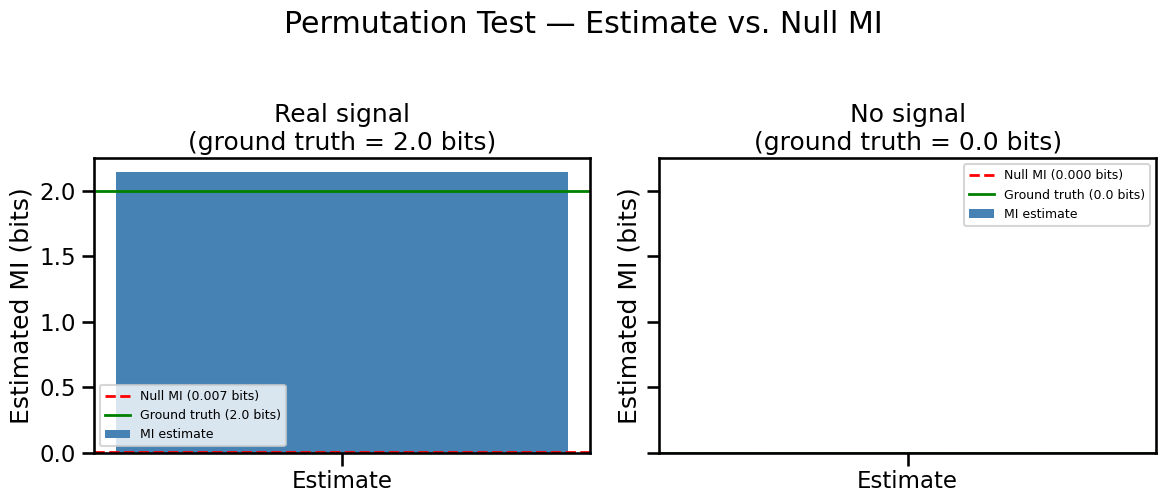

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, results, null_mi, label, gt in [
    (axes[0], results_real, null_mi_real,
     'Real signal\n(ground truth = 2.0 bits)', 2.0),
    (axes[1], results_null, null_mi_null,
     'No signal\n(ground truth = 0.0 bits)', 0.0),
]:
    # Plot estimate as a bar
    ax.bar(['Estimate'], [results.mi_estimate],
           color='steelblue', width=0.4, label='MI estimate')

    # Plot null as a horizontal dashed line
    if null_mi is not None:
        ax.axhline(y=null_mi, color='red', linestyle='--', linewidth=2,
                   label=f'Null MI ({null_mi:.3f} bits)')

    # Plot ground truth
    ax.axhline(y=gt, color='green', linestyle='-', linewidth=2,
               label=f'Ground truth ({gt:.1f} bits)')

    ax.set_title(label)
    ax.set_ylabel("Estimated MI (bits)")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)

plt.suptitle("Permutation Test — Estimate vs. Null MI", y=1.02)
plt.tight_layout()
plt.show()

In the real-signal case, the estimated MI should sit clearly above the null.
The gap between them — the signal-to-null margin — is your primary evidence
that the result is not a statistical artefact.

In the no-signal case, the estimated MI and null MI should both be close to
zero, and close to each other. If the estimate were substantially above the
null even here, it would indicate a problem: a wrong split mode, temporal
leakage, or some other methodological issue.

**Practical guidance:**

- Always run `permutation_test=True` alongside any final estimate you intend
  to report. The null MI costs one extra training run and provides a crucial
  sanity check.
- A large gap between estimate and null is necessary but not sufficient for
  a rigorous result. Always also run `mode='rigorous'` to correct for
  finite-sample bias (Tutorial 5).
- If the estimate and null are close even when you expect a real signal,
  revisit your split mode (Tutorial 3) and window size (Tutorial 4) before
  concluding that there is no relationship.

## 2. The InfoNCE Ceiling and the SMILE Estimator

The default MI estimator in NeuralMI is **InfoNCE**. It is stable
and works well for a wide range of problems. But it has a fundamental
mathematical limitation: the critic is trained with negative samples from each
training batch, so the effective optimization ceiling is tied to batch size.
In bits:

$$\text{InfoNCE ceiling} = \frac{\log(N_\text{batch})}{\log 2} \text{ bits}$$

For batch size 128, this is approximately 7 bits. For 64, approximately 6 bits.
If the true MI is much higher, InfoNCE may under-estimate.

Important implementation detail: NeuralMI evaluates MI on up to
`max_eval_samples` (default at 5000 samples or the size of the training dataset) 
points at evaluation time (potentially much larger than
`batch_size`). This means the reported bound can exceed the training-batch
ceiling, but optimization is still constrained by the training batches.

The **SMILE** estimator removes this ceiling. It uses a clipped
Donsker-Varadhan correction that is unbounded in principle. The tradeoff
is higher variance: SMILE estimates are noisier than InfoNCE, especially
at low MI values. The `clip` parameter (default 5.0) controls this tradeoff:
lower values reduce variance but reintroduce some bias.

In high-MI regimes, InfoNCE can flatten while SMILE may continue increasing,
but SMILE is typically noisier.

**When to use each estimator:**

- **InfoNCE** (default): use for almost everything. It is stable, fast, and
  sufficient whenever the true MI is below the batch-size ceiling. For a
  batch size of 128, this means MI below ~7 bits — which covers the vast
  majority of neuroscience applications.

- **SMILE**: use as a fallback when InfoNCE appears ceiling-limited after
  trying a larger batch size. Expect higher variance and tune `clip`.

- **Diagnosing a ceiling problem**: if your InfoNCE estimate is close to
  $\log(N_\text{batch}) / \log(2)$ bits, you may be hitting the ceiling.
  Double the batch size and re-run. If the estimate rises, the ceiling was
  the problem. If it stays the same, the ceiling is not limiting you.

## 3. Embedding Model Architectures

The embedding model maps raw windowed data from shape
`(batch, n_channels, window_size)` to a fixed-size embedding vector of
shape `(batch, embedding_dim)`. The choice of architecture determines what
kinds of temporal patterns the network can detect. NeuralMI provides six
options via the `embedding_model` parameter in `base_params`.

**MLP** (`embedding_model='mlp'`, default): flattens the input and processes
it through fully connected layers. Has no explicit notion of temporal order —
it treats the window as a bag of features. This is surprisingly effective for
many neural data problems, especially when the relevant information is in the
mean firing rate or low-order statistics of the window. Start here, and only
switch if MI estimates plateau below expectation.

**CNN** (`embedding_model='cnn'`): applies 1D convolutions along the time
axis. Detects local temporal patterns (e.g., a specific temporal motif in an
LFP trace) and is translation-equivariant — it finds the same pattern
regardless of when in the window it occurs. Use for LFP or EEG data where
you expect stereotyped temporal waveforms. The `kernel_size` parameter
controls the temporal extent of each filter.

**TCN** (`embedding_model='tcn'`): a temporal convolutional network with
dilated convolutions. Like a CNN but with exponentially growing receptive
fields — it can detect patterns spanning the full window length without
deep stacking. Use for LFP data with long-range temporal dependencies, or
when window sizes are large (> 200 samples). Generally preferable to a plain
CNN for longer windows.

**GRU** (`embedding_model='gru'`): a gated recurrent unit. Processes the
window sequentially, maintaining a hidden state that carries information
across the entire window. Appropriate for spike train data where the temporal
order of spikes within a window matters — for example, when estimating
precision-sensitive codes (Tutorial 6). The `bidirectional=True` option
processes the sequence in both directions and often improves performance.

**LSTM** (`embedding_model='lstm'`): similar to GRU but with an additional
cell state that gives it longer memory. Slightly slower to train than GRU
with similar practical performance on most neural data. Use GRU as the
default recurrent model; switch to LSTM if you have reason to believe
very long-range temporal dependencies are important.

**Transformer** (`embedding_model='transformer'`): uses self-attention to
relate every timepoint in the window to every other. The most expressive
architecture, but also the most data-hungry and slowest to train. Only use
the Transformer when: (a) you have a very large dataset (tens of thousands
of windows), (b) the window is long enough that local convolutional filters
miss important long-range structure, and (c) you have already confirmed that
simpler architectures are insufficient. The `nhead` parameter controls the
number of attention heads.

**Practical decision guide:**

| Data type | Recommended starting model |
|-----------|---------------------------|
| Binned spike counts (short windows, ≤ 50 bins) | `'mlp'` |
| Binned spike counts (longer windows, order matters) | `'gru'` |
| LFP / EEG (short windows) | `'mlp'` or `'cnn'` |
| LFP / EEG (long windows, > 200 samples) | `'tcn'` |
| Raw spike times (via spike processor) | `'gru'` |
| Large dataset, long windows, complex relationships | `'transformer'` |

In all cases, start with the MLP and switch only if you have evidence that
the architecture is the limiting factor — for example, if a sweep over
`hidden_dim` and `embedding_dim` shows that MI plateaus at a low value
regardless of capacity, suggesting the network cannot extract the relevant
features.

## 4. Custom Models

The built-in architectures cover the majority of neuroscience use cases,
but sometimes your data or scientific question requires something the library
does not provide — a specific convolutional design, a graph neural network
for population geometry, or a domain-specific preprocessing step baked into
the model.

NeuralMI provides two escape hatches:

1. **`custom_embedding_cls`**: supply a custom embedding class. The library
   uses its own critic architecture (e.g., `SeparableCritic`) but replaces
   the embedding network with yours. Your class must accept
   `(input_dim, hidden_dim, embed_dim, n_layers)` in its `__init__` — the
   library will instantiate it using the values from `base_params`.

2. **`custom_critic`**: supply a fully built critic instance. The library
   bypasses all internal model construction and uses your model directly.
   Your model must inherit from `nmi.models.BaseCritic` and its `forward`
   method must return a tuple `(scores, kl_loss)` where `scores` is a
   `(batch_size, batch_size)` tensor and `kl_loss` is a scalar (use
   `torch.tensor(0.0)` if not using a variational model).

We demonstrate both approaches on the same correlated Gaussian data.

In [5]:
x_custom, y_custom = nmi.generators.generate_correlated_gaussians(
    n_samples=5000, dim=5, mi=2.0
)

custom_base_params = {
    'n_epochs': 75,
    'patience': 15,
    'batch_size': 128,
    'hidden_dim': 64,
    'embedding_dim': 16,
    'n_layers': 2,
}

**Method 1: `custom_embedding_cls`** is the preferred approach when you want
to change the embedding network but keep the library's critic architecture
(e.g., `SeparableCritic`). The library instantiates your class automatically
using the values of `input_dim`, `hidden_dim`, `embedding_dim`, and `n_layers`
from `base_params`, so the `__init__` signature must accept exactly these four
arguments in this order.

In [6]:
class CustomSpectralEmbedding(nmi.models.BaseEmbedding):
    """A simple example: embedding via a linear projection followed by
    a nonlinearity. In practice this could be any architecture —
    a graph network, a wavelet transform, a domain-specific encoder."""

    def __init__(self, input_dim: int, hidden_dim: int,
                 embed_dim: int, n_layers: int):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(max(0, n_layers - 1)):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers.append(nn.Linear(hidden_dim, embed_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, n_channels, window_size) — flatten before linear
        return self.net(x.view(x.shape[0], -1))

print("CustomSpectralEmbedding defined.")

CustomSpectralEmbedding defined.


In [7]:
results_custom_cls = nmi.run(
    x_data=x_custom,
    y_data=y_custom,
    mode='estimate',
    split_mode='random',
    base_params=custom_base_params,
    custom_embedding_cls=CustomSpectralEmbedding,  # pass the CLASS, not an instance
    random_seed=42
)

print(f"Custom embedding class — MI estimate: "
      f"{results_custom_cls.mi_estimate:.3f} bits  "
      f"(ground truth: 2.000 bits)")

Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]

TypeError: CustomSpectralEmbedding.__init__() got an unexpected keyword argument 'use_spectral_norm'

**Method 2: `custom_critic`** gives complete control over the entire model.
The library bypasses all internal architecture logic and uses your critic
directly, so architecture parameters in `base_params` (`embedding_dim`,
`hidden_dim`, etc.) are ignored at model construction time. Your critic must
inherit from `nmi.models.BaseCritic` and its `forward` method must return
a tuple `(scores, kl_loss)` — where `scores` is a `(batch_size, batch_size)`
matrix of pairwise compatibility values and `kl_loss` is a scalar (set to
`torch.tensor(0.0)` for non-variational models). Pass a pre-built **instance**
to `nmi.run`, not the class.

In [8]:
class MyCustomCritic(nmi.models.BaseCritic):
    """A fully custom critic. This example uses a simple separable
    dot-product design, but the forward method could implement any
    scoring function over (x, y) pairs."""

    def __init__(self, input_dim: int, embed_dim: int = 16):
        super().__init__()
        self.embed_x = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, embed_dim)
        )
        self.embed_y = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, embed_dim)
        )

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        # x, y: (batch, n_channels, window_size) — flatten before embedding
        x_flat = x.view(x.shape[0], -1)
        y_flat = y.view(y.shape[0], -1)
        x_emb  = self.embed_x(x_flat)   # (batch, embed_dim)
        y_emb  = self.embed_y(y_flat)   # (batch, embed_dim)
        scores = torch.matmul(x_emb, y_emb.t())  # (batch, batch) score matrix
        kl_loss = torch.tensor(0.0, device=scores.device)
        return scores, kl_loss

# Instantiate with correct input_dim:
# With processor_type=None, the library reshapes (N, 5) → (N, 5, 1),
# so input_dim = n_channels × window_size = 5 × 1 = 5
my_critic = MyCustomCritic(input_dim=5, embed_dim=16)
print("MyCustomCritic defined and instantiated.")

MyCustomCritic defined and instantiated.


In [9]:
results_custom_critic = nmi.run(
    x_data=x_custom,
    y_data=y_custom,
    mode='estimate',
    split_mode='random',
    base_params=custom_base_params,   # architecture params ignored for custom critic
    custom_critic=my_critic,          # pass the INSTANCE, not the class
    random_seed=42
)

print(f"Custom critic — MI estimate: "
      f"{results_custom_critic.mi_estimate:.3f} bits  "
      f"(ground truth: 2.000 bits)")



























































Sequential Sweep Progress: 100%|██████████| 1/1 [00:04<00:00,  4.15s/it]

Custom critic — MI estimate: 2.093 bits  (ground truth: 2.000 bits)


Both custom approaches produce estimates close to the ground truth of 2.0 bits.
The three approaches — library default, custom embedding class, and custom critic
— differ only in architectural flexibility, not in the underlying estimation
procedure. All three use the same InfoNCE objective, the same training loop,
and the same data split. The custom models give you the freedom to adapt the
representation to your specific data modality, whether that means incorporating
domain knowledge, using a non-standard inductive bias, or connecting NeuralMI
to an existing model you have already trained.

In [10]:
print("--- Final Comparison ---")
print(f"Ground truth MI:          2.000 bits")
print(f"Default model (Tutorial 1 style):  "
      f"[run separately if desired]")
print(f"Custom embedding class:   "
      f"{results_custom_cls.mi_estimate:.3f} bits")
print(f"Custom critic:            "
      f"{results_custom_critic.mi_estimate:.3f} bits")

--- Final Comparison ---
Ground truth MI:          2.000 bits
Default model (Tutorial 1 style):  [run separately if desired]


NameError: name 'results_custom_cls' is not defined

## 5. Optimizer, Regularization, and Training Diagnostics

### 5a. Changing the optimizer

NeuralMI uses Adam by default (`optimizer='adam'`). You can switch to any
supported optimizer by passing its name as a top-level keyword argument.
Additional optimizer settings go in `optimizer_params`.

Supported names: `'adam'`, `'adamw'`, `'sgd'`, `'rmsprop'`, `'adagrad'`.
You can also pass a `torch.optim.Optimizer` **subclass** directly.

**When to change the optimizer:**
- `'adamw'` + `weight_decay` is the most common upgrade and a good first
  choice when overfitting is suspected (especially on small datasets).
- `'sgd'` + momentum can achieve better final generalisation on large
  datasets but is more sensitive to the learning rate schedule.
- Stick with `'adam'` for most routine analyses.

In [ ]:
# Default (Adam):
results_adam = nmi.run(
    x_data=x_real, y_data=y_real,
    mode='estimate',
    split_mode='random',
    base_params={'n_epochs': 50, 'hidden_dim': 64, 'embedding_dim': 32},
    random_seed=42,
    show_progress=False,
)

# AdamW with weight decay — useful when you suspect overfitting:
results_adamw = nmi.run(
    x_data=x_real, y_data=y_real,
    mode='estimate',
    split_mode='random',
    base_params={'n_epochs': 50, 'hidden_dim': 64, 'embedding_dim': 32},
    optimizer='adamw',
    optimizer_params={'weight_decay': 1e-4},
    random_seed=42,
    show_progress=False,
)

print(f"Adam:  {results_adam.mi_estimate:.3f} bits")
print(f"AdamW: {results_adamw.mi_estimate:.3f} bits")

### 5b. MLP regularization for small datasets

When you have few samples (< ~500 processed windows), the MLP is prone to
overfitting: train MI can be high while test MI stays near zero.
Two regularization options address this:

- `dropout` (float, default 0.0): adds a dropout layer after each hidden
  activation. Values in the 0.1–0.3 range are typical.
- `norm_layer` (`None` / `'layer'` / `'batch'`, default `None`): inserts
  a normalisation layer between the linear transformation and the activation.
  `'layer'` (LayerNorm) is the safer default: it is stable at any batch size.
  `'batch'` (BatchNorm1d) can be unstable when batch_size is small (< ~32).

These parameters go in `base_params` and apply to the MLP and VarMLP models.
They have no effect on CNN, GRU, LSTM, TCN, or Transformer architectures.

The library will also emit a `UserWarning` if it detects fewer than 500
processed windows, suggesting which parameters might help.

In [ ]:
# Simulate a small-dataset scenario
x_small, y_small = nmi.generators.generate_correlated_gaussians(
    n_samples=300, dim=5, mi=2.0
)

# No regularization (may overfit)
results_noreg = nmi.run(
    x_data=x_small, y_data=y_small,
    mode='estimate', split_mode='random',
    base_params={'n_epochs': 100, 'hidden_dim': 64, 'embedding_dim': 32, 'n_layers': 2},
    random_seed=42, show_progress=False,
)

# With dropout + LayerNorm + AdamW
results_reg = nmi.run(
    x_data=x_small, y_data=y_small,
    mode='estimate', split_mode='random',
    base_params={
        'n_epochs': 100,
        'hidden_dim': 32,
        'embedding_dim': 16,
        'n_layers': 2,
        'dropout': 0.2,
        'norm_layer': 'layer',
    },
    optimizer='adamw',
    optimizer_params={'weight_decay': 1e-3},
    random_seed=42, show_progress=False,
)

print(f"No regularization: {results_noreg.mi_estimate:.3f} bits  (ground truth 2.0)")
print(f"With regularization: {results_reg.mi_estimate:.3f} bits")

### 5c. Training diagnostics with `eval_train`

By default, only the test-set MI curve is tracked during training. Setting
`eval_train` gives you a per-epoch train-set MI curve alongside the test curve,
which is the most direct way to diagnose overfitting.

`eval_train` accepts:
- `False` (default) — no per-epoch train evaluation.
- `True` — evaluate on the full training subset (size capped by `max_eval_samples`).
- `float` in `(0, 1)` — use that fraction of training samples.
- `int >= 1` — use exactly that many training samples.

When `eval_train` is set, `result.details['train_mi_history']` is populated
and appears automatically on the training curve plot.

The result always includes `result.details['raw_train_mi']`: the actual
computed train-set MI regardless of whether the model generalised. If the
test MI stayed non-positive, `result.details['train_mi']` is set to 0 (the
estimate is not meaningful) while `raw_train_mi` preserves the true value
for diagnostic inspection. Both are reported in the same units as
`result.mi_estimate`.

In [ ]:
results_diag = nmi.run(
    x_data=x_real, y_data=y_real,
    mode='estimate', split_mode='random',
    base_params={'n_epochs': 80, 'hidden_dim': 64, 'embedding_dim': 32, 'patience': 30},
    eval_train=True,
    random_seed=42, show_progress=False,
)

print(f"Final test MI:       {results_diag.mi_estimate:.3f} bits")
print(f"Final train MI:      {results_diag.details.get('train_mi', 'n/a'):.3f} bits")
print(f"Train MI (raw):      {results_diag.details.get('raw_train_mi', 'n/a'):.3f} bits")

train_hist = results_diag.details.get('train_mi_history')
test_hist  = results_diag.details.get('test_mi_history')
if train_hist and test_hist:
    gap = max(train_hist) - max(test_hist)
    print(f"Train–test gap (peak): {gap:.3f} bits  "
          f"({'overfitting detected' if gap > 0.5 else 'gap is small'})")

# Plotting automatically shows both curves when train_mi_history is present.
# results_diag.plot()

### 5d. Learning-rate schedulers

By default the learning rate is fixed throughout training. Schedulers decay
it over time, which can help the model converge to a better minimum — or at
least help it settle rather than oscillating near one.

Pass a scheduler name as the top-level `scheduler` keyword (same pattern as
`optimizer`). Extra constructor arguments go in `scheduler_params`.

Supported names:
- **`'cosine'`** — `CosineAnnealingLR`: smoothly decays lr from its initial
  value to near zero over `n_epochs`. Best general-purpose choice.
- **`'cosine_warmup'`** — linear warm-up for the first 10 % of epochs, then
  cosine annealing. Helps when a large lr causes instability in early epochs.
- **`'step'`** — `StepLR`: reduces lr by ×0.1 every `n_epochs // 3` epochs.
- **`'plateau'`** — `ReduceLROnPlateau` monitoring test MI (mode='max'):
  cuts lr when MI stops improving.

You can also pass any `torch.optim.lr_scheduler` subclass directly.


In [ ]:
# Cosine schedule
results_cosine = nmi.run(
    x_data=x_real, y_data=y_real,
    mode='estimate', split_mode='random',
    base_params={'n_epochs': 80, 'hidden_dim': 64, 'embedding_dim': 32, 'patience': 40},
    scheduler='cosine',
    random_seed=42, show_progress=False,
)

# ReduceLROnPlateau
results_plateau = nmi.run(
    x_data=x_real, y_data=y_real,
    mode='estimate', split_mode='random',
    base_params={'n_epochs': 80, 'hidden_dim': 64, 'embedding_dim': 32, 'patience': 40},
    scheduler='plateau',
    scheduler_params={'patience': 10, 'factor': 0.5},
    random_seed=42, show_progress=False,
)

print(f'No scheduler:          {results_adam.mi_estimate:.3f} bits')
print(f'Cosine schedule:       {results_cosine.mi_estimate:.3f} bits')
print(f'ReduceLROnPlateau:     {results_plateau.mi_estimate:.3f} bits')
print('(ground truth: 2.000 bits)')


## 6. Key Takeaways

- **Always run `permutation_test=True`** alongside any MI estimate you intend
  to report. The null MI — estimated on shuffled data — is the single most
  important sanity check available. A real signal should sit well above the null.

- **InfoNCE has a ceiling of $\log(N_\text{batch})$ bits.** If your estimate
  is near this value, raise `batch_size` first. If that is not possible,
  switch to `estimator='smile'`. The ceiling is most likely to be a problem
  for internal dimensionality analyses (`mode='dimensionality'`) and other
  high-MI regimes.

- **SMILE has higher variance than InfoNCE.** Use it only when the ceiling
  is a real concern, not as a general improvement. For most neuroscience
  problems with MI below ~5 bits, InfoNCE is the better choice.

- **Start with the MLP embedding.** Only switch to a sequential model (GRU,
  LSTM) or convolutional model (CNN, TCN) if you have evidence that temporal
  order or local waveform structure matters and the MLP is failing to capture
  it. The Transformer is a last resort for large datasets with complex
  long-range structure.

- **`custom_embedding_cls`** replaces the embedding network while keeping the
  library's critic. Pass the class (not an instance). Its `__init__` must
  accept `(input_dim, hidden_dim, embed_dim, n_layers)`.

- **`custom_critic`** gives complete control. Pass an instance (not the class).
  It must inherit from `nmi.models.BaseCritic` and return `(scores, kl_loss)`
  from `forward`.

- **For small datasets (< ~500 windows):** add `dropout=0.2` and
  `norm_layer='layer'` to `base_params`, reduce `hidden_dim` and
  `embedding_dim`, and use `optimizer='adamw'` with
  `optimizer_params={'weight_decay': 1e-3}`. The library will warn you
  automatically when it detects a small sample count.

- **Use `eval_train=True` to diagnose overfitting.** A large gap between
  train MI and test MI means the model is memorising the training set.
  Reduce model size or add regularization until the gap is small.

- **`result.details['raw_train_mi']`** always contains the actual computed
  train-set MI, even when the model failed to generalise (in which case
  `result.details['train_mi']` is 0 and the raw value is kept for inspection).
  Both values are in the same units as `result.mi_estimate`.

- **`scheduler='cosine'` is the lowest-risk performance upgrade.** It adds no
  hyperparameters and consistently improves or matches the no-scheduler baseline.
  Use `'cosine_warmup'` when the early epochs are unstable; `'plateau'` when
  you do not know how many epochs to train for.

## Common Mistakes

1. **Not running the permutation test and trusting a positive estimate.**
   A positive MI estimate does not prove a real relationship. A wrong split
   mode, temporal leakage, or a bug in data alignment can all produce
   spuriously positive estimates. The permutation test is the cheapest
   available check — always run it.

2. **Assuming InfoNCE is always sufficient.** For most analyses it is. But
   if your estimate is near $\log(N_\text{batch}) / \log(2)$ bits, you may
   be underestimating the true MI. Always compute the ceiling for your batch
   size and check whether your estimate is close to it.

3. **Passing an instance to `custom_embedding_cls` or a class to
   `custom_critic`.** `custom_embedding_cls` expects a class — the library
   will instantiate it. `custom_critic` expects a pre-built instance — the
   library will use it directly. Mixing these up will raise an error or
   produce unexpected behaviour.

4. **Getting `input_dim` wrong for a custom model.** The input to the
   embedding is the flattened window: `n_channels × window_size`. For
   pre-processed data with no windowing (`processor_type=None`),
   `window_size=1`, so `input_dim = n_channels`. Always print the processed
   tensor shape from `nmi.data.handler.create_dataset` (Tutorial 2) if you
   are unsure.

5. **Choosing a complex embedding without first trying the MLP.** The MLP
   is a strong baseline that works surprisingly well even for temporal data.
   A GRU or Transformer that underperforms the MLP is usually a sign of
   insufficient training epochs or data, not an architecture problem.

## Conclusion: The Complete NeuralMI Workflow

You have completed the NeuralMI tutorial series. The full workflow, from
raw recording to publication-ready result, is:

1. **Format your data** (Tutorial 2): choose the right processor type,
   transpose to the correct shape, and let the library handle windowing
   and alignment.

2. **Choose the right split mode** (Tutorial 3): `'blocked'` for any
   continuous recording, `'random'` only for genuinely IID data.

3. **Find good parameters** (Tutorial 4): sweep `window_size` to find the
   plateau region, then sweep `hidden_dim` and `embedding_dim` to find the
   smallest sufficient architecture.

4. **Correct for bias** (Tutorial 5): use `mode='rigorous'` for any result
   you intend to report. Check `is_reliable` before trusting the estimate.

5. **Ask temporal questions** (Tutorial 6): use `mode='lag'` for delays,
   `mode='precision'` for spike-timing resolution, `mode='transfer'` for
   directed coupling.

6. **Ask population questions** (Tutorial 7): use `mode='dimensionality'`
   for intrinsic dimensionality, `return_embeddings=True` for representation
   geometry, `mode='conditional'` for controlling known variables.

7. **Validate and refine** (Tutorial 8): run `permutation_test=True`,
   check for the InfoNCE ceiling, choose an embedding architecture
   appropriate for your data, use custom models when needed, and apply
   optimizer / regularization / scheduler options to improve training dynamics
   and small-sample robustness.

The library documentation — `theory.md`, `concepts.md`, and the full API
reference — provides the mathematical foundations behind each of these steps.
The tutorials have given you the practical intuition; the documentation will
give you the rigour.